In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pandas.plotting import scatter_matrix

In [2]:
sns.set_style('whitegrid')

In [3]:
path = 'datasets/loan50.csv'
loan_50 = pd.read_csv(path)

In [4]:
loan_50.head()

,state,emp_length,term,homeownership,annual_income,verified_income,debt_to_income,total_credit_limit,total_credit_utilized,num_cc_carrying_balance,loan_purpose,loan_amount,grade,interest_rate,public_record_bankrupt,loan_status,has_second_income,total_income
0,NJ,3.0,60,rent,59000,Not Verified,0.557525,95131,32894,8,debt_consolidation,22000,B,10.90,0,Current,False,59000
1,CA,10.0,36,rent,60000,Not Verified,1.305683,51929,78341,2,credit_card,6000,B,9.92,1,Current,False,60000
2,SC,NaN,36,mortgage,75000,Verified,1.056280,301373,79221,14,debt_consolidation,25000,E,26.30,0,Current,False,75000
3,CA,0.0,36,rent,75000,Not Verified,0.574347,59890,43076,10,credit_card,6000,B,9.92,0,Current,False,75000
4,OH,4.0,60,mortgage,254000,Not Verified,0.238150,422619,60490,2,home_improvement,25000,B,9.43,0,Current,False,254000


In [5]:
num_columns = loan_50.select_dtypes(include='number').columns

array([[<Axes: xlabel='emp_length', ylabel='emp_length'>,
        <Axes: xlabel='term', ylabel='emp_length'>,
        <Axes: xlabel='annual_income', ylabel='emp_length'>,
        <Axes: xlabel='debt_to_income', ylabel='emp_length'>,
        <Axes: xlabel='total_credit_limit', ylabel='emp_length'>,
        <Axes: xlabel='total_credit_utilized', ylabel='emp_length'>,
        <Axes: xlabel='num_cc_carrying_balance', ylabel='emp_length'>,
        <Axes: xlabel='loan_amount', ylabel='emp_length'>,
        <Axes: xlabel='interest_rate', ylabel='emp_length'>,
        <Axes: xlabel='public_record_bankrupt', ylabel='emp_length'>,
        <Axes: xlabel='total_income', ylabel='emp_length'>],
       [<Axes: xlabel='emp_length', ylabel='term'>,
        <Axes: xlabel='term', ylabel='term'>,
        <Axes: xlabel='annual_income', ylabel='term'>,
        <Axes: xlabel='debt_to_income', ylabel='term'>,
        <Axes: xlabel='total_credit_limit', ylabel='term'>,
        <Axes: xlabel='total_credit_utili

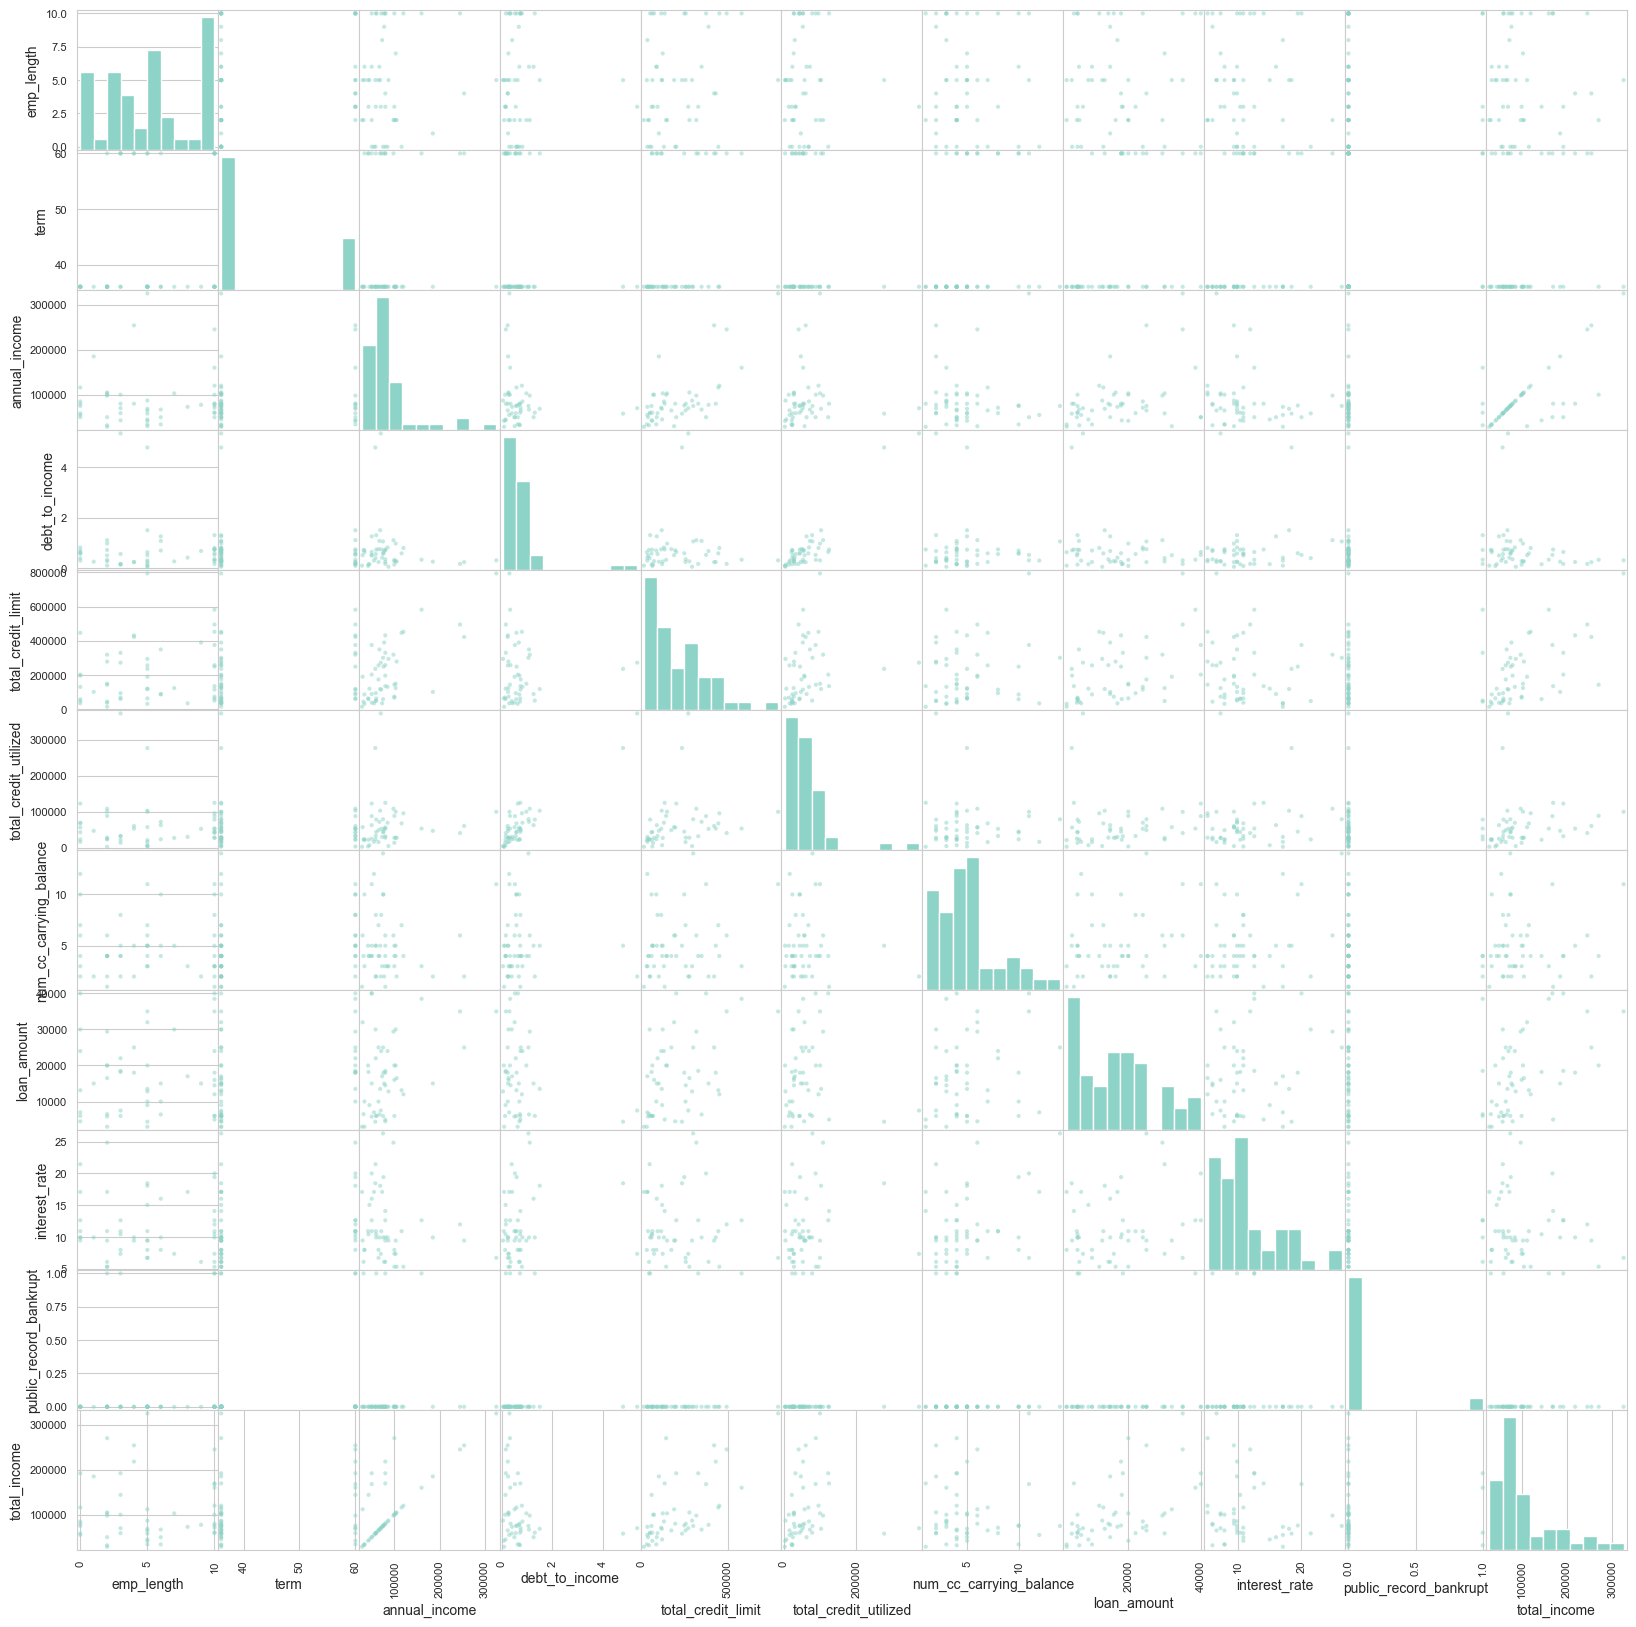

In [50]:
scatter_matrix(loan_50.select_dtypes(include='number'), figsize=(20,20))

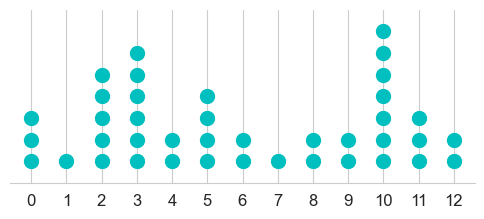

In [7]:
# Create random data
rng = np.random.default_rng(123) # random number generator
data = rng.integers(0, 13, size=40)
values, counts = np.unique(data, return_counts=True)

# Draw dot plot with appropriate figure size, marker size and y-axis limits
fig, ax = plt.subplots(figsize=(6, 2.25))
for value, count in zip(values, counts):
    ax.plot([value]*count, list(range(count)), 'co', ms=10, linestyle='')
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.yaxis.set_visible(False)
ax.set_ylim(-1, max(counts))
ax.set_xticks(range(min(values), max(values)+1))
ax.tick_params(axis='x', length=0, pad=8, labelsize=12)

plt.show()


In [8]:
# data = [11,15,50, 9, 6]
#
# mean = (11+15+50+9+6)/len(data) = 18.2 # Numpy np.mean(data)
# median = sorted(data)[len(data) // 2] = 11 # Numpy np.median(data)
# pop_variance = ((11-18.2)**2 + (15-18.2)**2 + (50-18.2)**2 + (9-18.2)**2 + (6-18.2)**2) / 5 = 261.36 # Numpy np.var(data)
# sample_var = ((11-18.2)**2 + (15-18.2)**2 + (50-18.2)**2 + (9-18.2)**2 + (6-18.2)**2) / (5 - 1) = 326.7 # Numpy np.var(data, ddof=1) коли маємо частину даних
# std = math.sqrt(pop_variance) | pow(var, 0.5) = 16.166632302368974 # Numpy np.std(data)
#
# right_skew = mean > median
# left_skew = mean < median
# balanced = mean ~= median
#
# Pearson skewness = 3(mean - median) / std # Numpy 3*(np.mean(data) - np.median(data)) / np.std(data)
# direct skewness = mean > median | mean < median | mean ~ median
# skewness formula = np.mean(((data - data.mean()) / np.std(data)) ** 3) # pd.Series(data).skew()

In [9]:
ir = loan_50['interest_rate'].dropna()

q1 = ir.quantile(0.25)
median = ir.median()
mean = ir.mean()
q3 = ir.quantile(0.75)
iqr = q3 - q1

# Standard Tukey whiskers
lower_whisker = ir[ir >= q1 - 1.5 * iqr].min()
upper_whisker = ir[ir <= q3 + 1.5 * iqr].max()

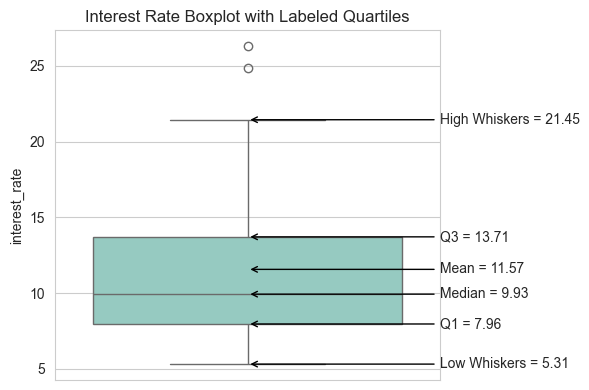

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=loan_50, y='interest_rate', ax=ax)

# Annotate Mean
ax.annotate(
    f"Mean = {mean:.2f}",
    xy=(0, mean),           # point on the boxplot
    xytext=(0.5, mean),     # text location
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='black'),
    va='center'
)

# Annotate Low Whiskers
ax.annotate(
    f"Low Whiskers = {lower_whisker:.2f}",
    xy=(0, lower_whisker),           # point on the boxplot
    xytext=(0.5, lower_whisker),     # text location
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='black'),
    va='center'
)

# Annotate High Whiskers
ax.annotate(
    f"High Whiskers = {upper_whisker:.2f}",
    xy=(0, upper_whisker),           # point on the boxplot
    xytext=(0.5, upper_whisker),     # text location
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='black'),
    va='center'
)

# Annotate median
ax.annotate(
    f"Median = {median:.2f}",
    xy=(0, median),           # point on the boxplot
    xytext=(0.5, median),     # text location
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='black'),
    va='center'
)

# Annotate Q1 and Q3
ax.annotate(
    f"Q1 = {q1:.2f}",
    xy=(0, q1),
    xytext=(0.5, q1),
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='black'),
    va='center'
)

ax.annotate(
    f"Q3 = {q3:.2f}",
    xy=(0, q3),
    xytext=(0.5, q3),
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='black'),
    va='center'
)

ax.set_title('Interest Rate Boxplot with Labeled Quartiles')
plt.tight_layout()
plt.show()

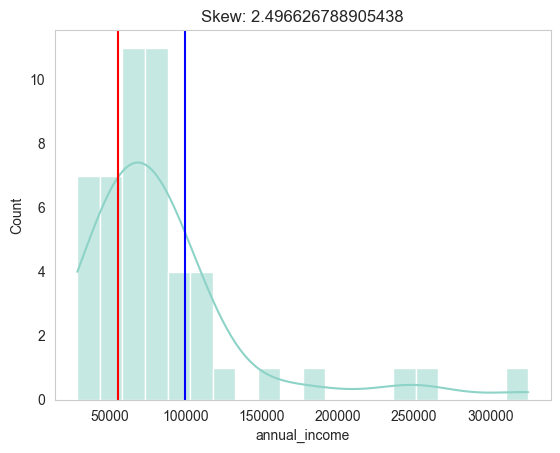

In [11]:
q1 = loan_50['annual_income'].quantile(0.25)
q3 = loan_50['annual_income'].quantile(0.75)
sns.histplot(data=loan_50, x='annual_income', bins=20, kde=True)
plt.axvline(q1, color='red')
plt.axvline(q3, color='blue')
plt.title(f'Skew: {loan_50['annual_income'].skew()}')
plt.grid(False)

In [12]:
mean = loan_50['annual_income'].mean()
median = loan_50['annual_income'].median()

Q1 = loan_50['annual_income'].quantile(0.25)
Q3 = loan_50['annual_income'].quantile(0.75)
IQR = Q3 - Q1

LTH = Q1 - 1.5*IQR
HTH = Q3 + 1.5*IQR

df = loan_50['annual_income'][loan_50['annual_income'].between(LTH, HTH)]

robust_median = df.median()
robust_mean = df.mean()

median_perc = median * 100 / robust_median
mean_perc = mean * 100 / robust_mean

print(
    f'Orig Mean: {mean}, Orig Median: {median}, Robust Mean: {robust_mean}, Robust Median: {robust_median}, Mean perc: {mean_perc}, Median Perc: {median_perc}'
)

Orig Mean: 86170.0, Orig Median: 74000.0, Robust Mean: 71728.26086956522, Robust Median: 70500.0, Mean perc: 120.13395969086226, Median Perc: 104.9645390070922


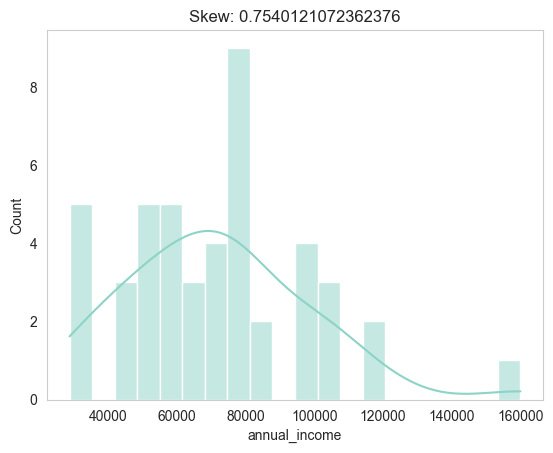

In [13]:
sns.histplot(data=df, bins=20, kde=True)
plt.title(f'Skew: {df.skew()}')
plt.grid(False)

In [14]:
# In skewed data most useful is median
print(f'Median: {df.median()}')
# When data have normal distribution we can use mean
print(f'Median: {df.mean()}')

Median: 70500.0
Median: 71728.26086956522


# Data Transformation

Hint:
+ Mild skew: try sqrt.
+ Medium–strong right skew (income, population, size, duration): log (np.log10, np.log).
+ Very strong skew and theory says “inverse”: consider 1/x, but check histogram/skew after.


In [26]:
rng = np.random.default_rng(123)

# Many values close to 0, few large ones (log-normal style)
# Uniform in [-4, 2] -> 10^x in [10^-4, 10^2]
x = rng.uniform(-4, 2, size=1000)
data = 10 ** x   # highly right-skewed, many observations near zero


In [31]:
df = pd.DataFrame({'population': data})

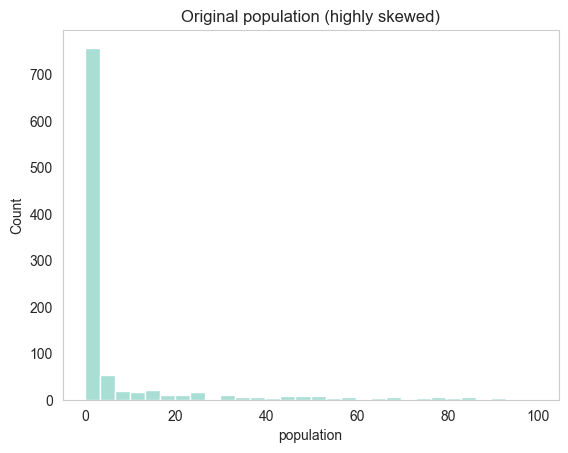

In [32]:
sns.histplot(df['population'], bins=30)
plt.title('Original population (highly skewed)')
plt.xlabel('population')
plt.grid(False)

In [38]:
# transformation
df['log10_population'] = np.log10(df['population'])
df['sqrt_population'] = np.sqrt(df['population'])
df['1_population'] = 1 / df['population']

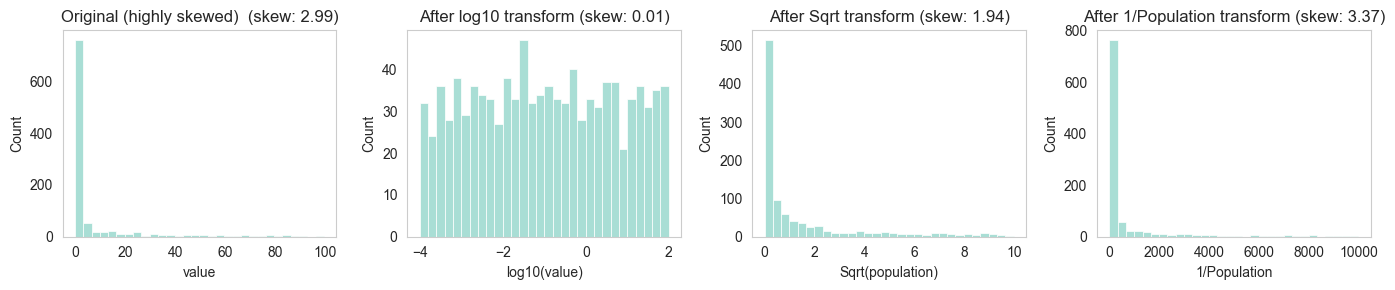

In [43]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))

# Original scale
sns.histplot(df['population'], bins=30, ax=axes[0])
axes[0].set_title(f'Original (highly skewed)  (skew: {np.round(df['population'].skew(), 2)})')
axes[0].set_xlabel('value')
axes[0].grid(False)

# Log10
sns.histplot(df['log10_population'], bins=30, ax=axes[1])
axes[1].set_title(f'After log10 transform (skew: {np.round(df['log10_population'].skew(), 2)})')
axes[1].set_xlabel('log10(value)')
axes[1].grid(False)

# Sqrt
sns.histplot(df['sqrt_population'], bins=30, ax=axes[2])
axes[2].set_title(f'After Sqrt transform (skew: {np.round(df['sqrt_population'].skew(), 2)})')
axes[2].set_xlabel('Sqrt(population)')
axes[2].grid(False)

# 1/Population
sns.histplot(df['1_population'], bins=30, ax=axes[3])
axes[3].set_title(f'After 1/Population transform (skew: {np.round(df['1_population'].skew(), 2)})')
axes[3].set_xlabel('1/Population')
axes[3].grid(False)

plt.tight_layout()
plt.show()

In [109]:
county = pd.read_csv('./datasets/county.csv')

<Axes: xlabel='pop2000', ylabel='Count'>

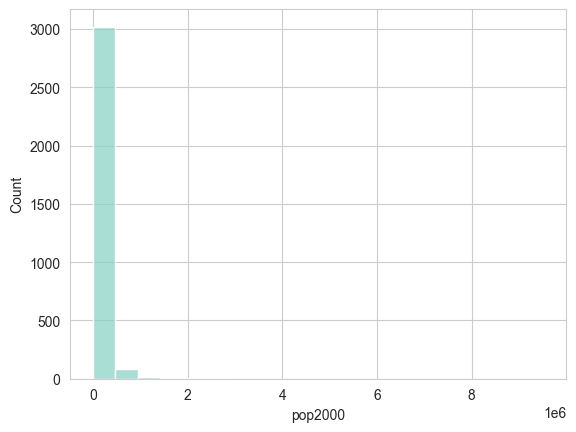

In [118]:
sns.histplot(county['pop2000'], bins=20)

In [112]:
county['pop_log10'] = np.log10(county['pop2000'])

<Axes: xlabel='pop_log10', ylabel='Count'>

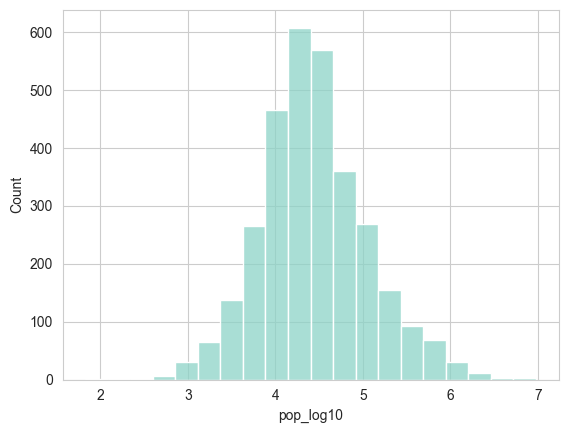

In [119]:
sns.histplot(county['pop_log10'], bins=20)

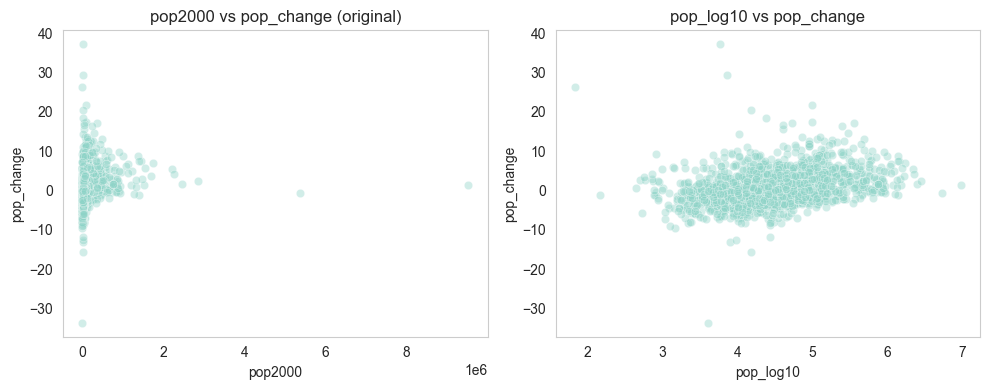

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 1. Original scale
sns.scatterplot(
    data=county.sample(2000, random_state=0),  # sample to avoid overplotting
    x='pop2000', y='pop_change', alpha=0.4, ax=axes[0]
)
axes[0].set_title('pop2000 vs pop_change (original)')
axes[0].grid(False)

# 2. Transformed y
sns.scatterplot(
    data=county.sample(2000, random_state=0),
    x='pop_log10', y='pop_change', alpha=0.4, ax=axes[1]
)
axes[1].set_title('pop_log10 vs pop_change')
axes[1].grid(False)

plt.tight_layout()
plt.show()

In [115]:
spearman_log = county['pop_change'].corr(county['pop_log10'], method='spearman')
pearson_log = county['pop_change'].corr(county['pop_log10'], method='pearson')
pearson_corr = county['pop_change'].corr(county['pop2000'], method='pearson')
spearman_corr = county['pop_change'].corr(county['pop2000'], method='spearman')

print("Pearson (pop_change vs pop2000):      ", pearson_corr)
print("Pearson (pop_change vs pop_log10): ", pearson_log)

print("Spearman (pop_change vs pop2000):    ", spearman_corr)
print("Spearman (pop_change vs pop_log10):", spearman_log)

Pearson (pop_change vs pop2000):       0.15413290501799368
Pearson (pop_change vs pop_log10):  0.3157789558006854
Spearman (pop_change vs pop2000):     0.362140671799407
Spearman (pop_change vs pop_log10): 0.362140671799407


In [3]:
mammals = pd.read_csv('./datasets/mammals.csv')

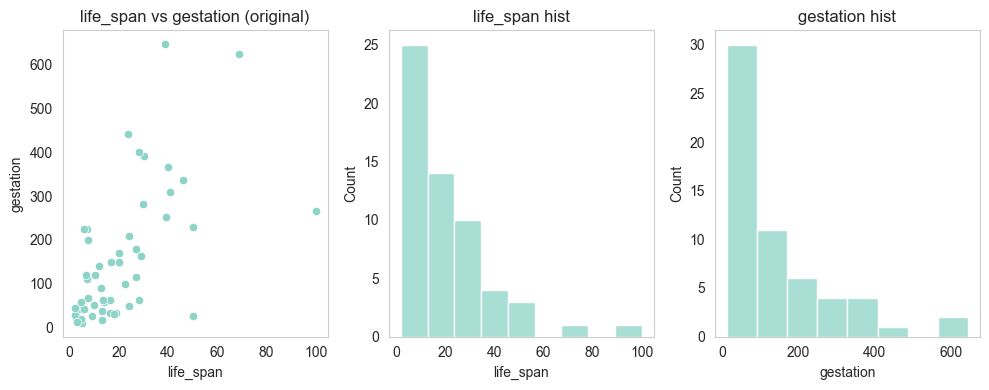

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# 1. Original scale
sns.scatterplot(data=mammals, x='life_span', y='gestation', ax=axes[0])
axes[0].set_title('life_span vs gestation (original)')
axes[0].grid(False)

# 2. life_span hist
sns.histplot(data=mammals, x='life_span', ax=axes[1])
axes[1].set_title('life_span hist')
axes[1].grid(False)

# 2. gestation hist
sns.histplot(data=mammals, x='gestation', ax=axes[2])
axes[2].set_title('gestation hist')
axes[2].grid(False)

plt.tight_layout()
plt.show()

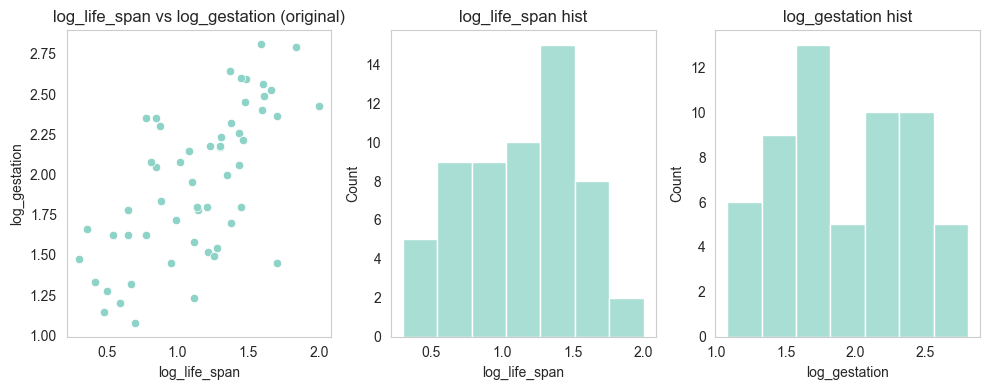

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

mammals['log_life_span'] = np.log10(mammals['life_span'])
mammals['log_gestation'] = np.log10(mammals['gestation'])

# 1. Original scale
sns.scatterplot(data=mammals, x='log_life_span', y='log_gestation', ax=axes[0])
axes[0].set_title('log_life_span vs log_gestation (original)')
axes[0].grid(False)

# 2. life_span hist
sns.histplot(data=mammals, x='log_life_span', ax=axes[1])
axes[1].set_title('log_life_span hist')
axes[1].grid(False)

# 2. gestation hist
sns.histplot(data=mammals, x='log_gestation', ax=axes[2])
axes[2].set_title('log_gestation hist')
axes[2].grid(False)

plt.tight_layout()
plt.show()

In [12]:
orig_pearson = mammals['life_span'].corr(mammals['gestation'], method='pearson')
log_pearson = mammals['log_life_span'].corr(mammals['log_gestation'], method='pearson')

print(f'Orig corr: {orig_pearson}')
print(f'Log10 corr: {log_pearson}')

Orig corr: 0.6148487915437162
Log10 corr: 0.6611693859137424


In [16]:
print("Skew life_span:", mammals['life_span'].skew())
print("Skew gestation:", mammals['gestation'].skew())

print("Skew log_life_span:", mammals['log_life_span'].skew())
print("Skew log_gestation:", mammals['log_gestation'].skew())

Skew life_span: 2.013759505306088
Skew gestation: 1.6835007981286436
Skew log_life_span: -0.17169382793256155
Skew log_gestation: 0.04988301449295721


In [15]:
pearson_orig = mammals['life_span'].corr(mammals['gestation'], method='pearson')
pearson_log  = mammals['log_life_span'].corr(mammals['log_gestation'], method='pearson')

spearman_orig = mammals['life_span'].corr(mammals['gestation'], method='spearman')
spearman_log  = mammals['log_life_span'].corr(mammals['log_gestation'], method='spearman')

print("Pearson original:", pearson_orig)
print("Pearson log-log:", pearson_log)
print("Spearman original:", spearman_orig)
print("Spearman log-log:", spearman_log)

Pearson original: 0.6148487915437162
Pearson log-log: 0.6611693859137424
Spearman original: 0.6728017476791572
Spearman log-log: 0.6728017476791572


## Categorical Data

In [3]:
loans = pd.read_csv('./datasets/loans_full_schema.zip')

In [16]:
loans.pivot_table(index='application_type', columns='homeownership', values=None, aggfunc='size', fill_value=0)

homeownership,MORTGAGE,OWN,RENT
application_type,,,
individual,3839,1170,3496
joint,950,183,362


<Axes: xlabel='homeownership', ylabel='count'>

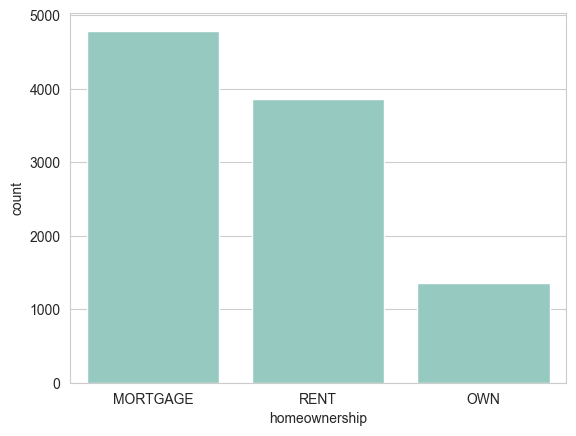

In [21]:
sns.barplot(loans['homeownership'].value_counts())

In [22]:
pt = loans.pivot_table(
    index='application_type',
    columns='homeownership',
    values=None,
    aggfunc='size',
    fill_value=0
)
pt_prop_row = pt.div(pt.sum(axis=1), axis=0)
pt_prop_row

homeownership,MORTGAGE,OWN,RENT
application_type,,,
individual,0.451382,0.137566,0.411052
joint,0.635452,0.122408,0.242140
